# 02 — Sentiment Analysis
VADER sentiment on posts and comments


In [1]:
# Shared Setup — run this first
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import seaborn as sns, warnings, re
from collections import Counter
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

POSTS_FILE    = "../data/posts_soccer.json"
COMMENTS_FILE = "../data/comments_soccer.json"

with open(POSTS_FILE, "r", encoding="utf-8") as f:
    posts_raw = json.load(f)
with open(COMMENTS_FILE, "r", encoding="utf-8") as f:
    comments_raw = json.load(f)

posts_df = pd.DataFrame([{
    "id": p.get("id"), "author": p.get("author"),
    "title": p.get("title",""), "selftext": p.get("selftext",""),
    "score": p.get("score",0), "upvote_ratio": p.get("upvote_ratio",0),
    "num_comments": p.get("num_comments",0), "subreddit": p.get("subreddit"),
    "flair": p.get("link_flair_text"), "created_utc": p.get("created_utc"),
} for p in posts_raw])

comments_df = pd.DataFrame([{
    "id": c.get("id"), "author": c.get("author"),
    "body": c.get("body",""), "score": c.get("score",0),
    "parent_id": c.get("parent_id"), "link_id": c.get("link_id"),
    "subreddit": c.get("subreddit"), "created_utc": c.get("created_utc"),
    "controversiality": c.get("controversiality",0),
} for c in comments_raw])

REMOVE = [None, "[deleted]", "AutoModerator", "BotDefense"]
posts_df["datetime"]    = pd.to_datetime(posts_df["created_utc"], unit="s")
comments_df["datetime"] = pd.to_datetime(comments_df["created_utc"], unit="s")
posts_df    = posts_df[~posts_df["author"].isin(REMOVE)].reset_index(drop=True)
comments_df = comments_df[~comments_df["author"].isin(REMOVE)].reset_index(drop=True)
posts_df["full_text"] = posts_df["title"] + " " + posts_df["selftext"].fillna("")

print(f"Posts: {len(posts_df):,} | Comments: {len(comments_df):,}")
print(f"Date range: {posts_df["datetime"].min().date()} to {posts_df["datetime"].max().date()}")


Posts: 18,088 | Comments: 45,020
Date range: 2022-10-31 to 2022-12-19


## 3. Sentiment Analysis
Using VADER (Valence Aware Dictionary and Sentiment Reasoner) — designed for social media text.

In [2]:
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

sia = SentimentIntensityAnalyzer()

# ── SCORE COMMENTS ─────────────────────────────────────────────────────────
print('Running VADER on comments...')
sentiments = []
for body in tqdm(comments_df['body']):
    scores = sia.polarity_scores(str(body))
    sentiments.append(scores)

sent_df = pd.DataFrame(sentiments)
comments_df['vader_pos']      = sent_df['pos']
comments_df['vader_neg']      = sent_df['neg']
comments_df['vader_neu']      = sent_df['neu']
comments_df['vader_compound'] = sent_df['compound']
comments_df['sentiment_label'] = comments_df['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)

# ── SCORE POSTS ────────────────────────────────────────────────────────────
print('Running VADER on post titles...')
post_sentiments = [sia.polarity_scores(str(t)) for t in tqdm(posts_df['title'])]
post_sent_df = pd.DataFrame(post_sentiments)
posts_df['vader_compound'] = post_sent_df['compound']
posts_df['sentiment_label'] = posts_df['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)

print('\nComment Sentiment Distribution:')
print(comments_df['sentiment_label'].value_counts())
print(f'\nMean compound score (comments): {comments_df["vader_compound"].mean():.4f}')

Running VADER on comments...


  0%|                                                                                                                                                                | 0/45020 [00:00<?, ?it/s]

  1%|█▉                                                                                                                                                  | 588/45020 [00:00<00:07, 5868.10it/s]

  3%|███▉                                                                                                                                               | 1219/45020 [00:00<00:07, 6126.83it/s]

  4%|█████▉                                                                                                                                             | 1832/45020 [00:00<00:07, 5481.71it/s]

...

 76%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                   | 13662/18088 [00:00<00:00, 18044.75it/s]

 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                    | 15519/18088 [00:00<00:00, 18204.06it/s]

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 17377/18088 [00:00<00:00, 18318.02it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18088/18088 [00:00<00:00, 18532.65it/s]


Comment Sentiment Distribution:
sentiment_label
Positive    20060
Neutral     12932
Negative    12028
Name: count, dtype: int64

Mean compound score (comments): 0.1116


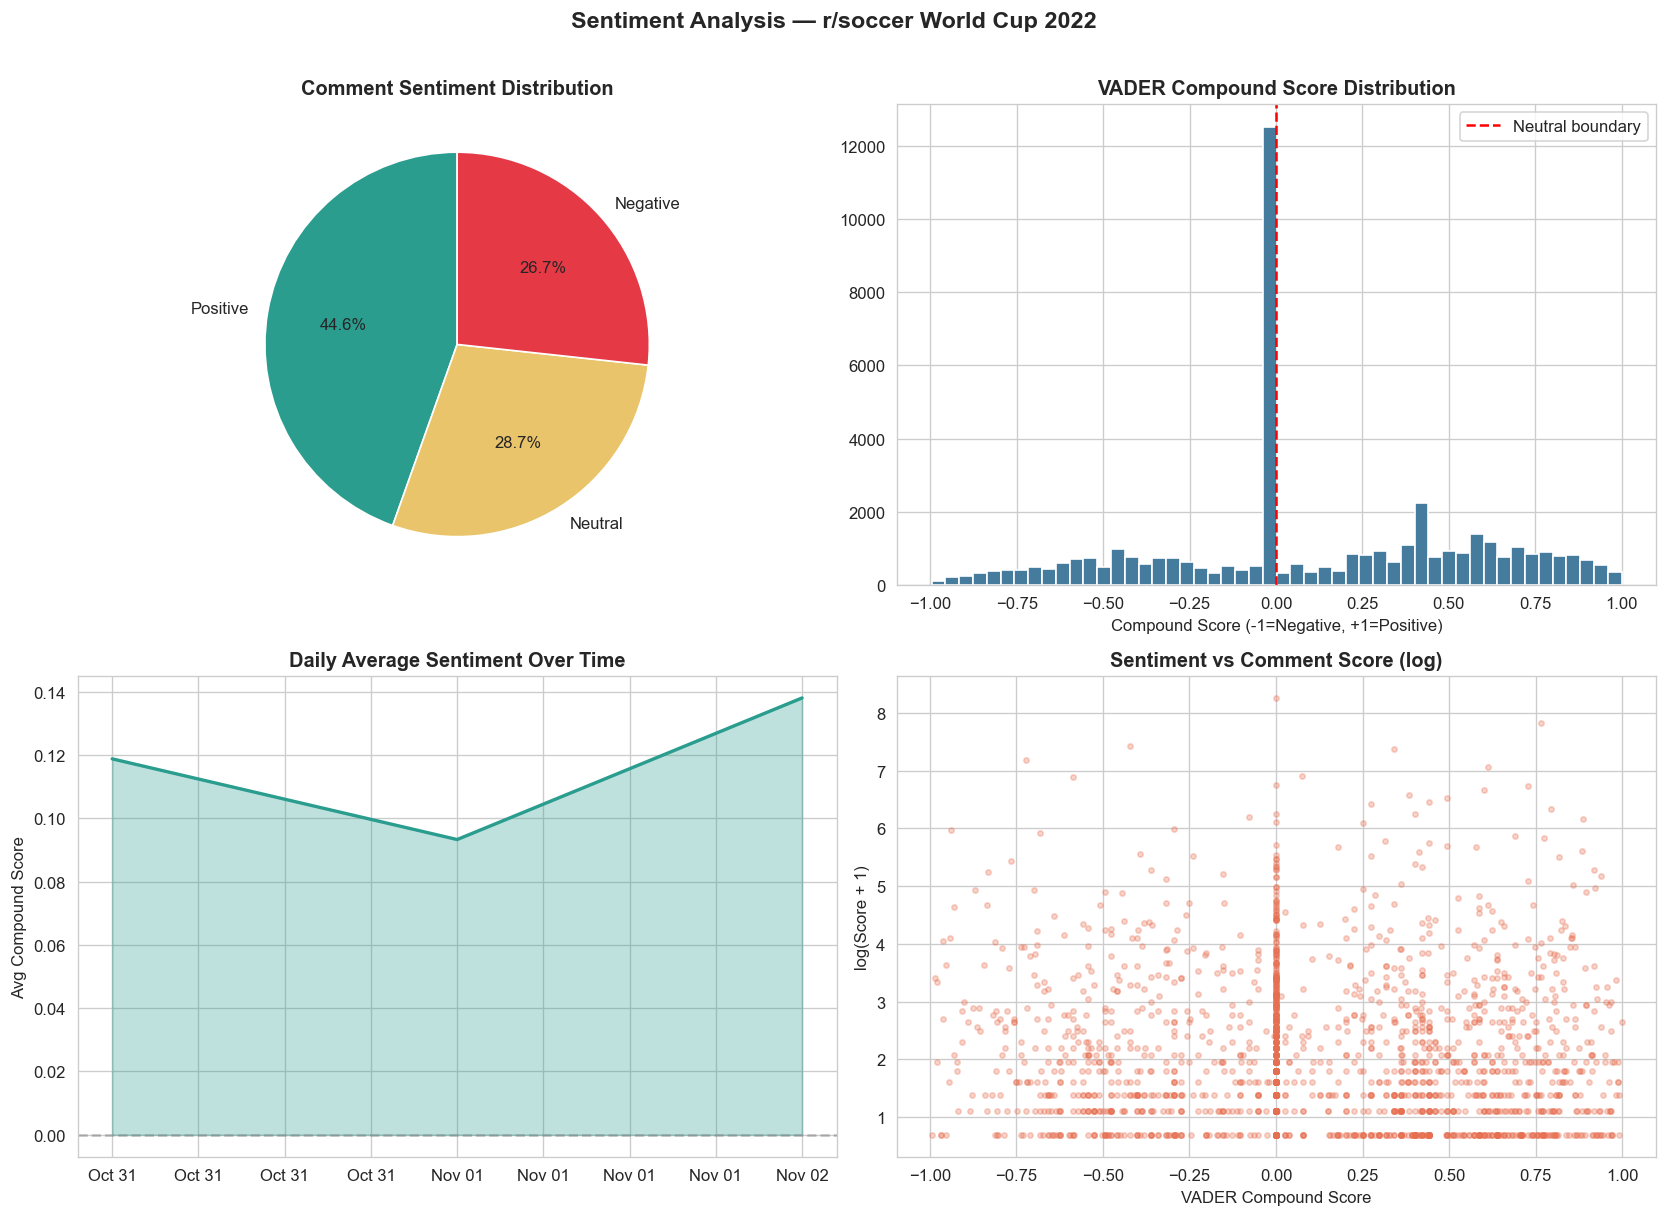

Saved: sentiment_analysis.png


In [3]:
# ── SENTIMENT VISUALISATIONS ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment label pie
label_counts = comments_df['sentiment_label'].value_counts()
colors = ['#2a9d8f', '#e9c46a', '#e63946']
axes[0,0].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
              colors=colors, startangle=90)
axes[0,0].set_title('Comment Sentiment Distribution', fontweight='bold')

# 2. Compound score histogram
axes[0,1].hist(comments_df['vader_compound'], bins=50, color='#457b9d', edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', label='Neutral boundary')
axes[0,1].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0,1].set_xlabel('Compound Score (-1=Negative, +1=Positive)')
axes[0,1].legend()

# 3. Sentiment over time (daily average)
daily_sentiment = comments_df.set_index('datetime').resample('D')['vader_compound'].mean()
axes[1,0].plot(daily_sentiment.index, daily_sentiment.values, color='#2a9d8f', linewidth=2)
axes[1,0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1,0].fill_between(daily_sentiment.index, daily_sentiment.values, 0,
                        where=daily_sentiment.values >= 0, alpha=0.3, color='#2a9d8f')
axes[1,0].fill_between(daily_sentiment.index, daily_sentiment.values, 0,
                        where=daily_sentiment.values < 0, alpha=0.3, color='#e63946')
axes[1,0].set_title('Daily Average Sentiment Over Time', fontweight='bold')
axes[1,0].set_ylabel('Avg Compound Score')
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# 4. Sentiment vs score
sample = comments_df[comments_df['score'] > 0].sample(min(2000, len(comments_df)))
axes[1,1].scatter(sample['vader_compound'], np.log1p(sample['score']),
                  alpha=0.3, color='#e76f51', s=10)
axes[1,1].set_title('Sentiment vs Comment Score (log)', fontweight='bold')
axes[1,1].set_xlabel('VADER Compound Score')
axes[1,1].set_ylabel('log(Score + 1)')

plt.suptitle('Sentiment Analysis — r/soccer World Cup 2022', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sentiment_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: sentiment_analysis.png')

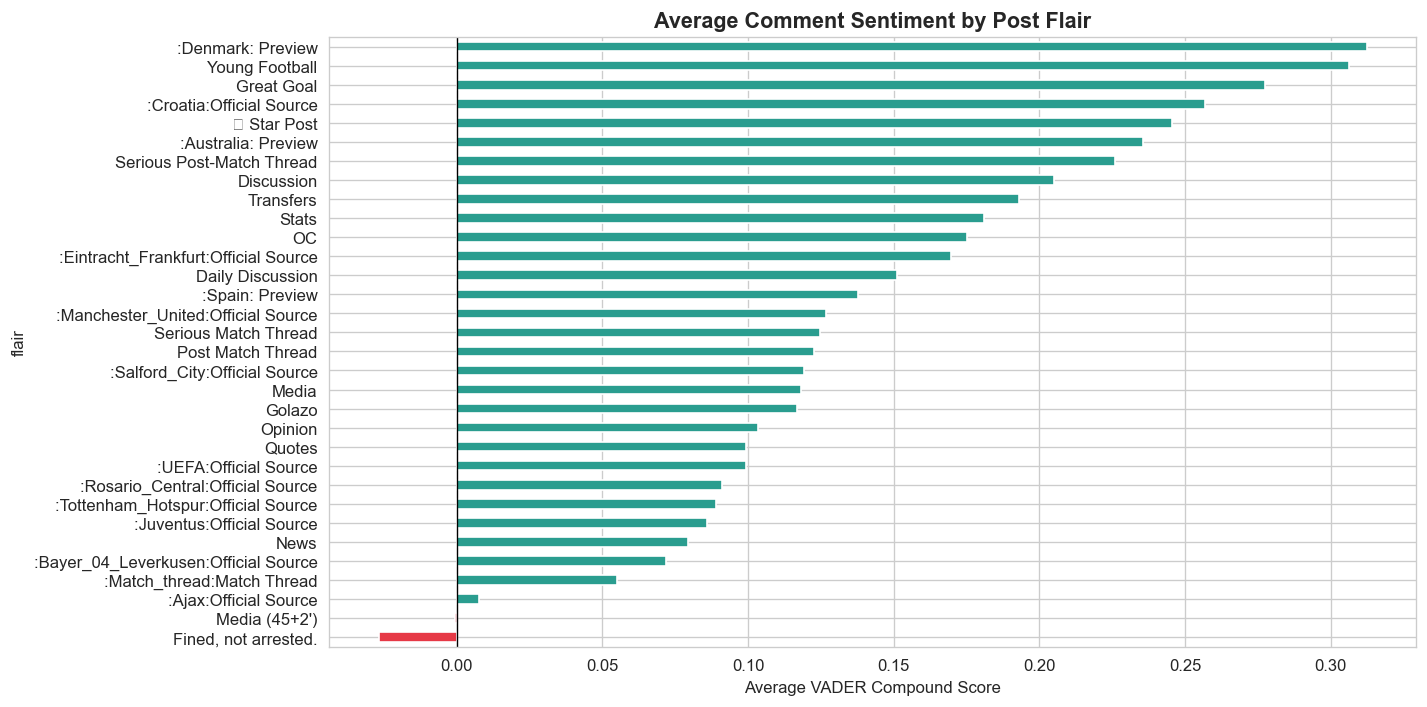

In [4]:
# ── SENTIMENT BY FLAIR ─────────────────────────────────────────────────────
# Join flair from posts to comments via link_id
posts_flair = posts_df[['id', 'flair']].copy()
comments_df['post_id'] = comments_df['link_id'].str[3:]  # strip 't3_'
comments_with_flair = comments_df.merge(posts_flair, left_on='post_id', right_on='id', how='left')

flair_sentiment = (comments_with_flair
    .dropna(subset=['flair'])
    .groupby('flair')['vader_compound']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean')
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e63946' if x < 0 else '#2a9d8f' for x in flair_sentiment['mean']]
flair_sentiment['mean'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Average Comment Sentiment by Post Flair', fontsize=13, fontweight='bold')
ax.set_xlabel('Average VADER Compound Score')
plt.tight_layout()
plt.savefig('sentiment_by_flair.png', bbox_inches='tight')
plt.show()